# 🚂 TARDIS Project — PREDICTING THE UNPREDICTABLE
***

### The Research Team :
* **Raphaël Permentier**
* **Stan Gaumain**
* **Come Chaslerie**

---
### **Our Mission:** 

**Analyse train database, find out why trains are late, and build a program to predict train delays before they happen.**

---
### **Preliminary Step**

**To do this, we first looked closely at our data. We found some mistakes and missing information. We need to clean and fix these problems before we can build our prediction models.**

---
##### **First, we load the file containing the database so that we can modify it :**

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#load all mendatory lib

#put name of the file in filepath variable
filepath = "dataset.csv"
#load the file in variable df (Dataframe)
df = pd.read_csv(filepath, sep=";")

# 🧼 **CLEANING THE DATASET** #

---
### **Cleaning the Dataset**
---

To clean our data, we follow these simple steps:

* **1. Fix Data Types** We change each column to the right type. For example, we convert text into numbers so the computer can read them correctly.

* **2. Delete aberrant values** We remove aberrant values.
  
* **3. Remove Broken Rows** We delete rows that are missing important information because we cannot use them.
  
* **4. Fill Empty Spaces** If some columns have missing values, we fill them with 0, None or an average number.
  
* **5. Clean Extra Spaces** We remove invisible spaces at the beginning and the end of text columns (like station names) so they match perfectly.
  
* **6. Create New Columns** We build new information (features) from our data to help our prediction models work better later.

* **7. Delete Useless Columns** We remove text columns (like comments) that we do not need for our machine learning models.

* **8. Export Cleaned Dataset** We save our final, perfectly clean data into a new CSV file.
---

### ♻️ **Step 1 : Convert all columns to the appropriate type :**

**the columns type before :**

In [167]:
#print all columns type
print(df.dtypes)

Date                                                                             str
Service                                                                          str
Departure station                                                                str
Arrival station                                                                  str
Average journey time                                                             str
Number of scheduled trains                                                       str
Number of cancelled trains                                                       str
Cancellation comments                                                            str
Number of trains delayed at departure                                            str
Average delay of late trains at departure                                        str
Average delay of all trains at departure                                         str
Departure delay comments                                         

⚠️ **The Problem:**
Right now, some columns have the wrong data type. This will cause errors when we try to use the data in our models.

💡 **Our Fix:**
We write code to fix this. It automatically changes text columns into strings and number columns into numbers.

In [168]:
cols_to_num = [
    'Average journey time', 
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

cols_to_string = [
    'Service',
    'Departure station',
    'Arrival station',
    'Cancellation comments',
    'Departure delay comments',
    'Arrival delay comments'
]

#repeats the transformation for each column of the "cols_to_num" list
for col_num in cols_to_num:
    #convert columns to a str type
    df[col_num] = df[col_num].astype("string")
    #replace all ',' to '.' to transform into numeric
    df[col_num] = df[col_num].str.replace(',', '.')
    #Remove all the "min" characters so that you can then convert to numeric without any problems.
    df[col_num] = df[col_num].str.replace(' min', '')
    #Remove all the "%" characters so that you can then convert to numeric without any problems.
    df[col_num] = df[col_num].str.replace('%', '')
    #Converted the column to numeric type (string to numeric)
    df[col_num] = pd.to_numeric(df[col_num], errors='coerce')
for col_str in cols_to_string:
    #convert columns to a str type
    df[col_str] = df[col_str].astype("string")
#convert columns 'Date' to a datetime type with format year-month
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
#Keep only the months and years to ensure the data has the same format.
df['Date'] = df['Date'].dt.to_period('M')

**The columns type after conversion :**

In [169]:
print(df.dtypes)

Date                                                                             period[M]
Service                                                                             string
Departure station                                                                   string
Arrival station                                                                     string
Average journey time                                                               Float64
Number of scheduled trains                                                         Float64
Number of cancelled trains                                                         Float64
Cancellation comments                                                               string
Number of trains delayed at departure                                              Float64
Average delay of late trains at departure                                          Float64
Average delay of all trains at departure                                           Float64

**We can observe that the column types are now adapted and are therefore easier to use in our models later.**

---

### 🗑️ **Step 2 : Delete aberrant values :**

***

**Find all aberrant values and analyze them to determine how to handle them because these values ​​may cause models to fail.** 



***
**We create a function to generate a graph that will allow us to see the impact of our cleaning on this step**

In [170]:
# Set the background style of the graphs to a clean white grid
sns.set_theme(style="whitegrid")
# Function to draw a single scatter plot with specific points
def plot_delay_dispersion(dataset, graph, couleur, label, axe_x, axe_y):
    # Draw the points using the X and Y columns provided
    sns.scatterplot(
        data=dataset, 
        x = axe_x, 
        y = axe_y,
        color = couleur,      # Set the color of the points
        alpha = 0.6,          # Make points slightly transparent to see overlaps
        label = label,        # Set the text for the legend
        ax = graph            # Put the plot inside the specific figure window
    )
    # Set the text labels for the horizontal and vertical axes
    graph.set_xlabel(axe_x)
    graph.set_ylabel(axe_y)
# Main function to create the complete graph comparing before and after data
def scatterplot_graphique(df_before, df_after, title, axe_x, axe_y):
    # Find and isolate the rows that were deleted during the cleaning step
    df_removed = df_before.drop(index=df_after.index, errors='ignore')
    # Create a new blank window for the graph with a custom size
    fig, ax = plt.subplots(figsize=(10, 6))
    # Draw the deleted rows as red points
    plot_delay_dispersion(df_removed, ax, "#e74c3c", "deleted points", axe_x, axe_y)
    # Draw the kept rows as green points on the same graph
    plot_delay_dispersion(df_after, ax, "#2ecc71", "kept points", axe_x, axe_y)
    # Add the main title at the top of the graph
    ax.set_title(title)
    # Display the final graph on the screen
    plt.show()

In [171]:
# Function to draw a scatter plot showing the remaining trains
def point_graph(df, graph, couleur, label):
    # Calculate the Y value: Scheduled trains minus cancelled and delayed ones
    var_Y = df['Number of scheduled trains'] - df['Number of cancelled trains'] - df['Number of trains delayed at departure']
    # Draw the points on the graph
    sns.scatterplot(
        data=df,              # The dataset to use
        y = var_Y,            # The calculated values for the vertical axis
        x = var_Y.index,      # The row numbers (index) for the horizontal axis
        color = couleur,      # Set the color of the points
        alpha = 0.6,          # Make the points slightly transparent
        label = label,        # Add a name for the legend
        ax = graph            # Place this plot inside our specific graph window
    )
    # Add text labels to the horizontal and vertical axes
    graph.set_xlabel("index df")
    graph.set_ylabel("graph number of scheduled - cancel train - delayed train")
# Main function to compare and visualize kept vs. deleted rows
def invalid_nb_cancel_graph(old_df, df):
    # Isolate the deleted rows by dropping the ones that still exist in the new dataset
    df_removed = old_df.drop(index=df.index, errors='ignore')
    # Create a new blank graph with a specific width and height
    fig, ax = plt.subplots(figsize=(10, 6))
    # Draw the deleted rows as red points
    point_graph(df_removed, ax, "#e74c3c", "deleted points")
    # Draw the kept rows as green points on the same graph
    point_graph(df, ax, "#2ecc71", "kept points")
    # Add a title at the top of the graph
    ax.set_title("graph number of scheduled - cancel train - delayed train")
    # Force the top of the vertical axis to stop at 20 so the graph doesn't get squished
    plt.ylim(top=20)
    # Draw a thick red horizontal line exactly at the zero mark to spot negative values
    plt.axhline(y=0, color='red', linewidth=3)
    # Display the final graph on the screen
    plt.show()

In [172]:
# Function to draw the scatter plot checking for delay logic errors
def point_graph_delays(dataset, graph, couleur, label):
    # Calculate the difference between total delays and >15 min delays
    diff1 = dataset['Number of trains delayed at arrival'] - dataset['Number of trains delayed > 15min']
    # Calculate the difference between >15 min delays and >30 min delays
    diff2 = dataset['Number of trains delayed > 15min'] - dataset['Number of trains delayed > 30min']
    # Calculate the difference between >30 min delays and >60 min delays
    diff3 = dataset['Number of trains delayed > 30min'] - dataset['Number of trains delayed > 60min']
    # Combine the three differences and keep only the smallest one (the worst case)
    var_Y = pd.concat([diff1, diff2, diff3], axis=1).min(axis=1)
    # Draw the points on the graph
    sns.scatterplot(
        data=dataset,     # The data to use
        y=var_Y,          # The worst difference value goes on the vertical axis
        x=var_Y.index,    # The row number (index) goes on the horizontal axis
        color=couleur,    # Set the color of the points
        alpha=0.6,        # Make the points slightly transparent
        label=label,      # Add a name for the legend
        ax=graph          # Place this plot inside our specific graph window
    )
    # Add text labels for the horizontal and vertical axes
    graph.set_xlabel("index df")
    graph.set_ylabel("discrepancy on the delays)")
# Main function to compare the original data with the cleaned data
def invalid_delay_graph(old_df, current_df):
    # Find and isolate the rows that were deleted during the cleaning process
    df_removed = old_df.drop(index=current_df.index, errors='ignore')
    # Create a new blank graph with a specific size
    fig, ax = plt.subplots(figsize=(10, 6))
    # Draw the deleted rows as red points
    point_graph_delays(df_removed, ax, "#e74c3c", "delete line")
    # Draw the kept rows as green points on the same graph
    point_graph_delays(current_df, ax, "#2ecc71", "kept line")
    # Add a main title at the top of the graph
    ax.set_title("delay logic check")
    # Set the maximum height of the vertical axis to 20 so it doesn't get too tall
    plt.ylim(top=20) 
    # Draw a thick red horizontal line exactly at zero (logic errors will fall below this line)
    plt.axhline(y=0, color='red', linewidth=3)
    # Display the final graph on the screen
    plt.show()

***
**We will generate an initial graph to observe the values ​​we find to be aberrant.**

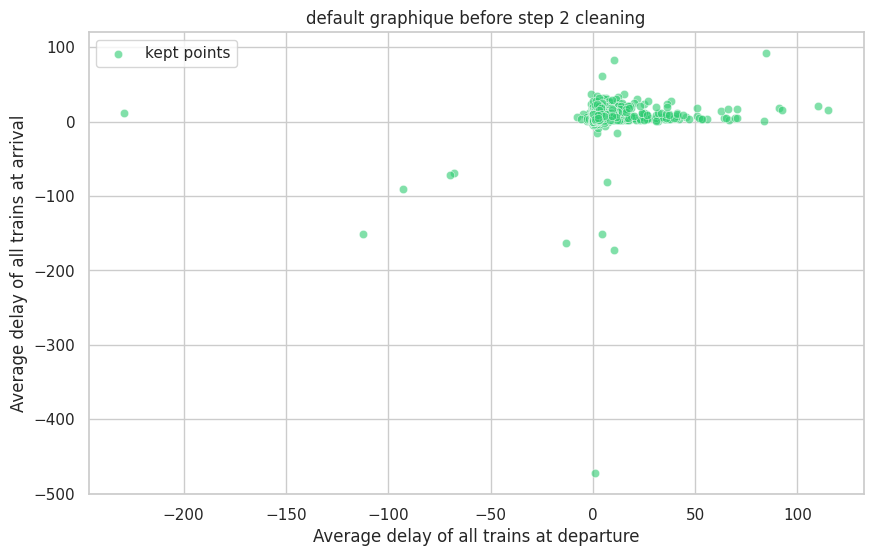

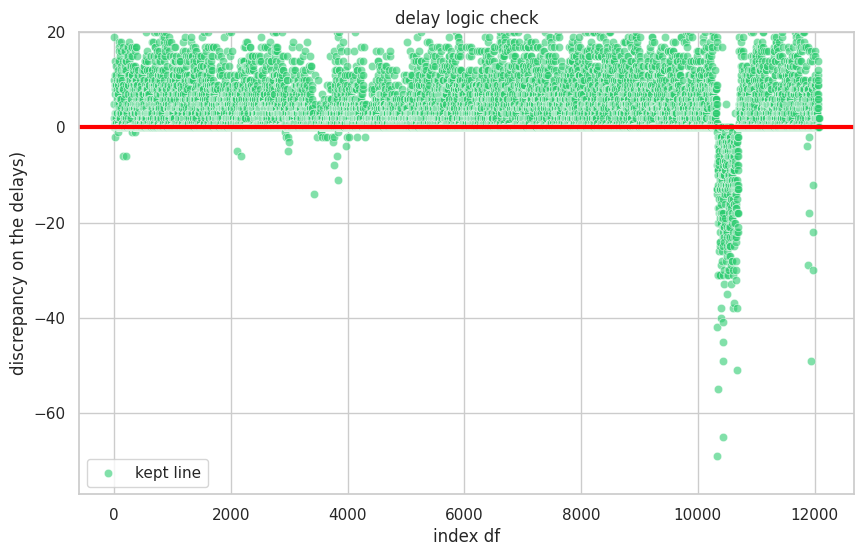

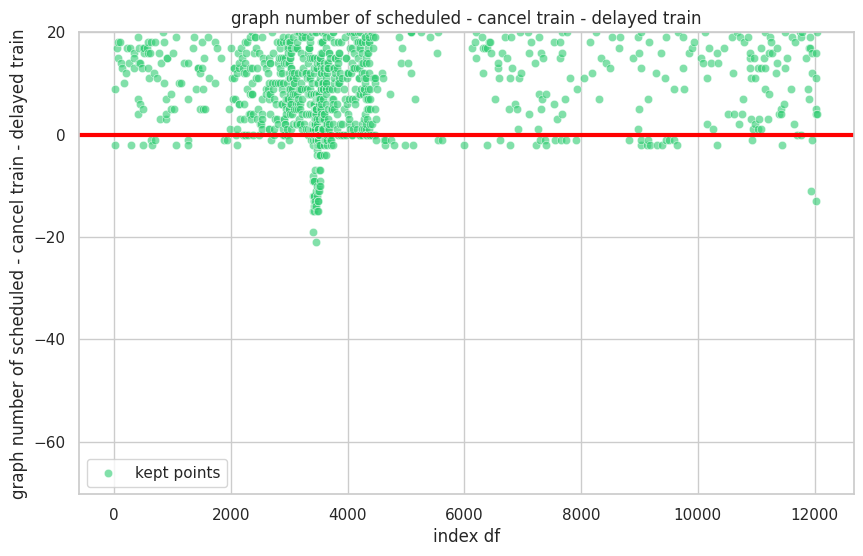

In [173]:
#call to the graphs before cleaning to observe
scatterplot_graphique(df, df, "default graphique before step 2 cleaning", "Average delay of all trains at departure", "Average delay of all trains at arrival")
invalid_delay_graph(df, df)
invalid_nb_cancel_graph(df, df)

***

**We find some impossible values :**

* **Average journey time < 1**

* **negative number in delayed train columns**

* **Invalid train counts**

* **Invalid logic delay trains**

#### **Handle the negative number in delayed train columns :**
**We create a function that checks if the value of each column in the "negative_delay" list is negative. If so, we delete the corresponding row, because a negative value is impossible in that column (for example: a negative number of trains).**

In [174]:
#list of all columns about delay train
negative_delay = [
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min'
]

def negative_delay_func(line, index, negative_list):
    # Loop for each column in negative_delay
    for col in negative_delay:
        value = line[col]
        # If the value exists and is less than 0
        if pd.notna(value) and value < 0:
            # Add the line index to our deletion list
            negative_list.append(index)
            # Stop checking this line to save time
            break


***
#### **Handle Average journey time < 1 or > 550 :**
**We create a function that checks if the value in the "Average journey time" column is less than 1 or greater than 600 because during the analysis of the graph previously, we saw that some values ​​are in these ranges and are aberrantly different from other values ​​(absurdly higher or lower).**

In [175]:
def wrong_average_journey(line, index, average_journey_list):
    # Extract the average journey time for this row
    value = line['Average journey time']
    # If the time exists and is less than 1
    if pd.notna(value) and (value < 1 or value > 550):
        # Add the row index to our deletion list
        average_journey_list.append(index)

***
#### **Invalid train counts :**
**We are verifying the accuracy of the number of canceled and delayed trains because we noticed that at certain times there are more canceled trains than originally scheduled trains, which is impossible. Therefore, we are creating a function to check this and removing the column if the values ​​are impossible.**

In [176]:
def invalid_train_count(line, index, invalid_count_list):
    scheduled = line['Number of scheduled trains']
    cancelled = line['Number of cancelled trains']
    delayed = line['Number of trains delayed at departure']

    if pd.notna(scheduled) and pd.notna(cancelled):
        if cancelled > scheduled:
            invalid_count_list.append(index)
            return
    if pd.notna(scheduled) and pd.notna(cancelled) and pd.notna(delayed):
        if (scheduled - cancelled - delayed < 0):
            invalid_count_list.append(index)
            return

***
#### **Invalid logic delay trains :**
**We are verifying the accuracy of the number of trains delayed by a certain amount because we noticed that at certain times there are more trains delayed by 30 minutes or more than trains delayed by 10 minutes or more, which is impossible since a train delayed by 30 minutes is also delayed by more than 10 minutes. We are creating a function to detect this and we are removing the line if the value is impossible.**

In [177]:
# Function to check if the delay numbers make logical sense for a specific row
def invalid_delay_logic(line, index, invalid_logic_list):
    # Get the total number of delayed trains
    delayed = line['Number of trains delayed at arrival']
    # Get the number of trains delayed for more than 15 minutes
    delayed_15 = line['Number of trains delayed > 15min']
    # Get the number of trains delayed for more than 30 minutes
    delayed_30 = line['Number of trains delayed > 30min']
    # Get the number of trains delayed for more than 60 minutes
    delayed_60 = line['Number of trains delayed > 60min']
    # 1. Check if both values exist AND if >15min delays are greater than the total delays
    if pd.notna(delayed) and pd.notna(delayed_15) and (delayed_15 > delayed):
        # If true, it's a logic error! Add the row number to our delete list
        invalid_logic_list.append(index)
        # Stop checking this row and exit the function
        return
    # 2. Check if both values exist AND if >30min delays are greater than >15min delays
    if pd.notna(delayed_15) and pd.notna(delayed_30) and (delayed_30 > delayed_15):
        # If true, it's a logic error! Add the row number to our delete list
        invalid_logic_list.append(index)
        # Stop checking this row and exit the function
        return
    # 3. Check if both values exist AND if >60min delays are greater than >30min delays
    if pd.notna(delayed_30) and pd.notna(delayed_60) and (delayed_60 > delayed_30):
        # If true, it's a logic error! Add the row number to our delete list
        invalid_logic_list.append(index)
        # Stop checking this row and exit the function
        return

***
#### **Too hight value delay:**
**We noticed that some lag values ​​are aberrantly high. We chose to remove these values ​​to standardize our data and avoid skewing the model if it takes on an extremely high value when it's just a very specific case or an error during data entry.**

In [178]:
# Function to find rows where the average delay is suspiciously high
def too_high_value(line, index, hight_value_list):
    # Get the average delay time when trains leave the station
    start = line['Average delay of all trains at departure']
    # Get the average delay time when trains arrive at their destination
    end = line['Average delay of all trains at arrival']
    # Check if both of these values actually exist (they are not empty)
    if pd.notna(start) and pd.notna(end):
        # Check if the departure delay is over 80 minutes OR the arrival delay is over 40 minutes
        if (start > 80) or (end > 40):
            # If it is true, this value is too extreme! Add the row number to our list
            hight_value_list.append(index)

**We apply all the created functions to a loop that calls the functions on each line to check the reliability of the information on that line and whether we can keep it or not; then we delete all the non-essential information.**

In [179]:
# Initialize empty lists to store the indexes of bad lines for each error type
negative_list = []
average_journey_list = []
invalid_count_list = []
invalid_logic_list = []
hight_value_list = []
# Main Loop: check every line in the dataset one by one
for index in df.index:
    # Extract the current line data
    line = df.loc[index]
    negative_delay_func(line, index, negative_list)
    wrong_average_journey(line, index, average_journey_list)
    invalid_train_count(line, index, invalid_count_list)
    invalid_delay_logic(line, index, invalid_logic_list)
    too_high_value(line, index, hight_value_list)

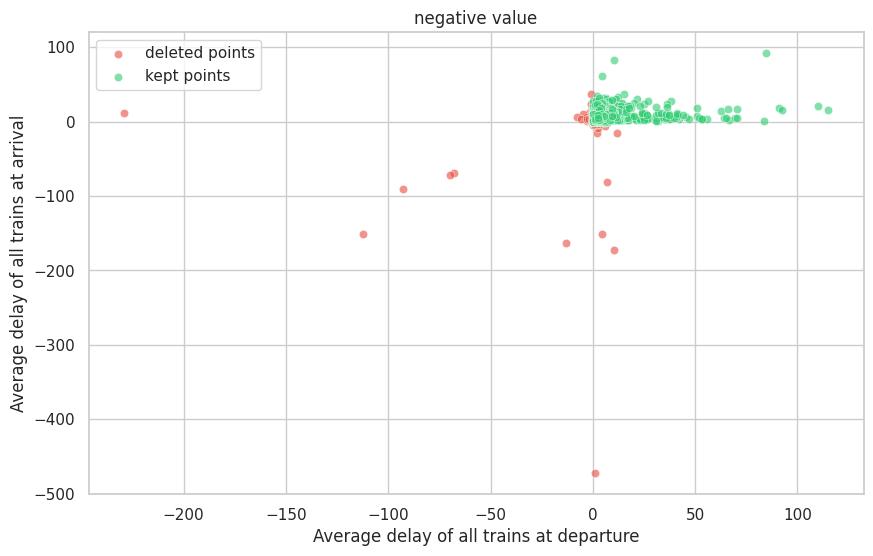

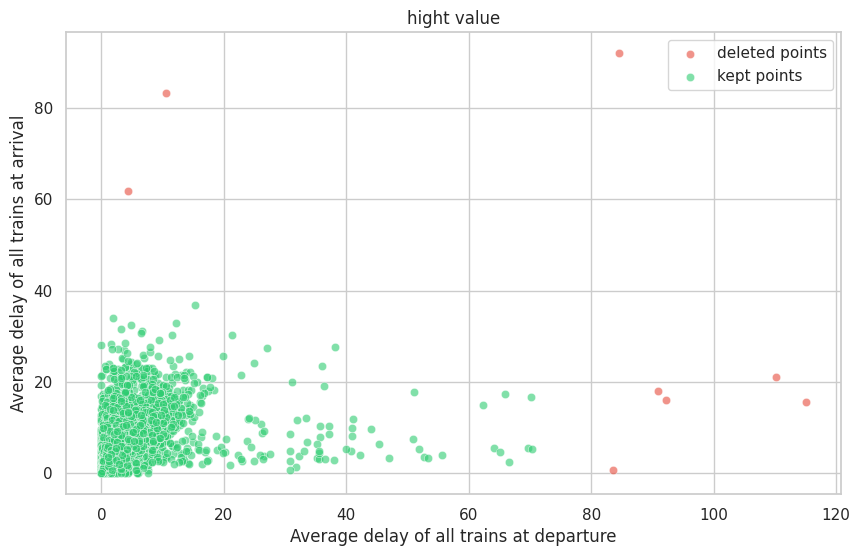

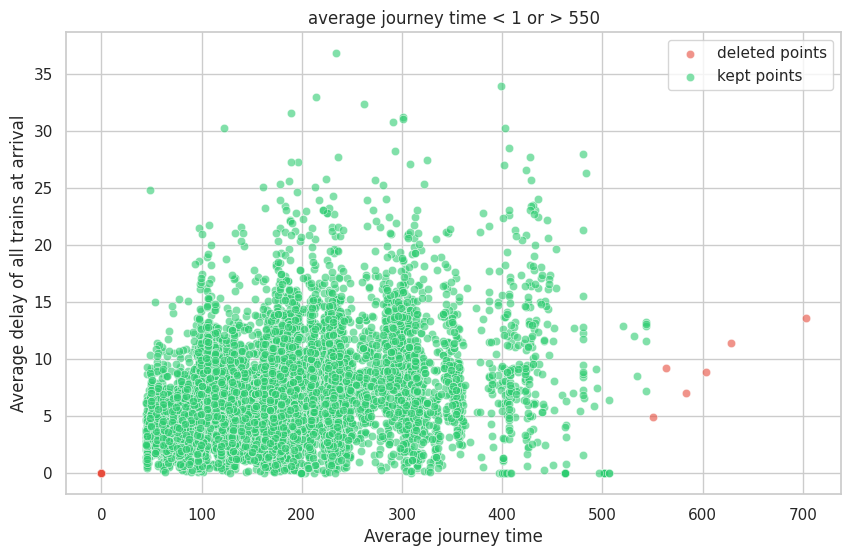

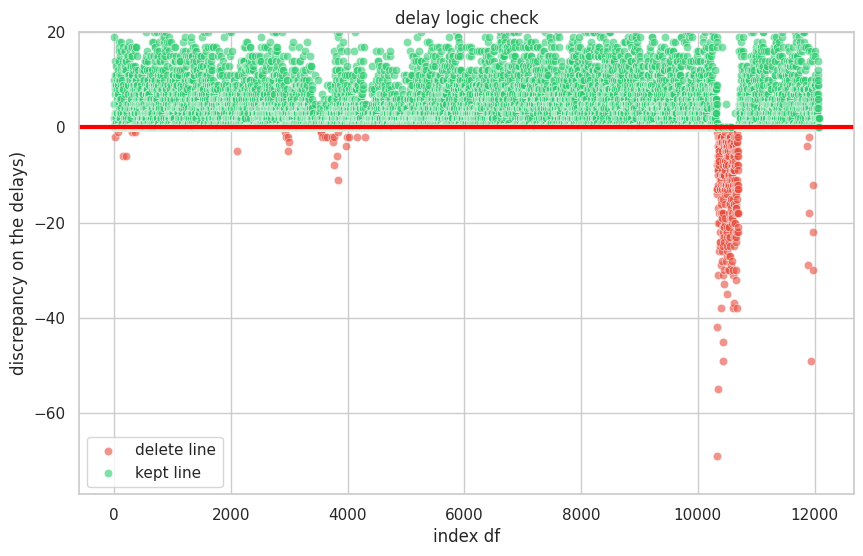

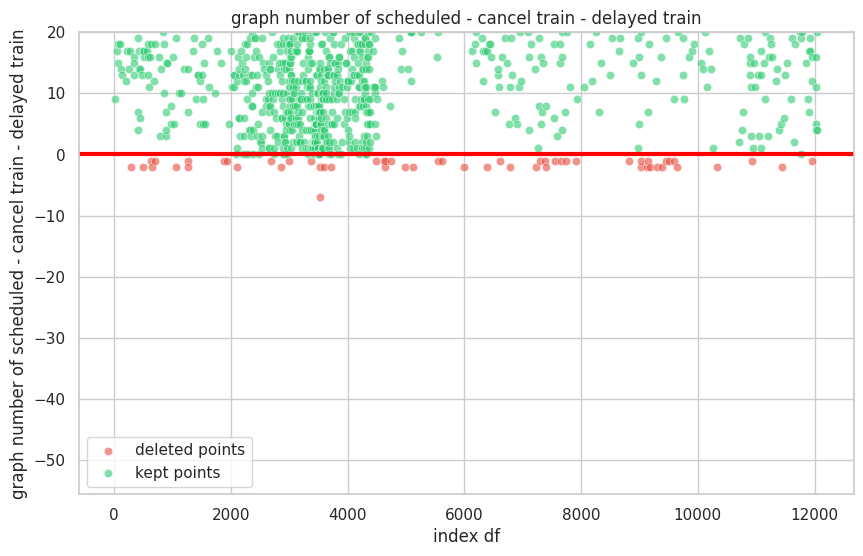

In [180]:
# Delete all the bad lines from the dataset at once and show a graphic in each delete
old_df = df
df = df.drop(index=negative_list, errors='ignore')
scatterplot_graphique(old_df, df, "negative value", "Average delay of all trains at departure", "Average delay of all trains at arrival")
old_df = df
df = df.drop(index=hight_value_list, errors='ignore')
scatterplot_graphique(old_df, df, "hight value", "Average delay of all trains at departure", "Average delay of all trains at arrival")
old_df = df
df = df.drop(index=average_journey_list, errors='ignore')
scatterplot_graphique(old_df, df, "average journey time < 1 or > 550", "Average journey time", "Average delay of all trains at arrival")
old_df = df
df = df.drop(index=invalid_logic_list, errors='ignore')
invalid_delay_graph(old_df, df)
old_df = df
df = df.drop(index=invalid_count_list, errors='ignore')
invalid_nb_cancel_graph(old_df, df)

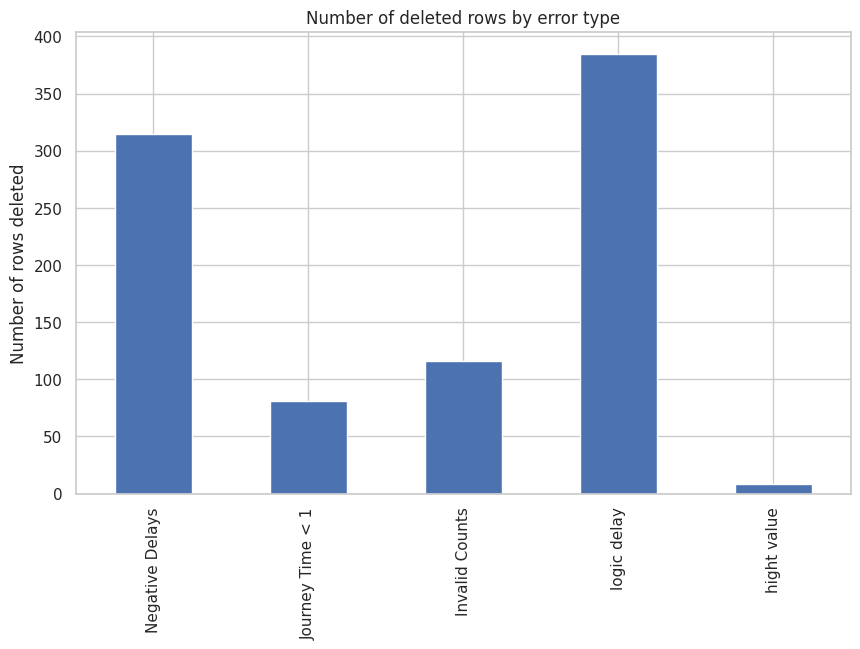

In [181]:
#Calculate the length (number of errors) for each list
len_negative = len(negative_list)
len_journey = len(average_journey_list)
len_invalid = len(invalid_count_list)
len_logic = len(invalid_logic_list)
len_hight = len(hight_value_list)
#Create a Pandas Series with our data and labels
data = pd.Series({'Negative Delays': len_negative, 'Journey Time < 1': len_journey, 'Invalid Counts': len_invalid, 'logic delay': len_logic, 'hight value': len_hight})
#Create the graphic structure (width: 10, height: 6)
plt.figure(figsize=(10, 6))
#select bar graphic style
data.plot(kind='bar')
#Add titles and labels to make it clear
plt.title("Number of deleted rows by error type")
#Add label to the y axe
plt.ylabel("Number of rows deleted")
#Show the graphic
plt.show()

**Result:** The graph shows that the rows with aberrant values have been correctly removed for each case. Our code worked as expected!

### 🗑️ **Step 3 : remove unsable line :**

**The number of line before delete unsable line :**

In [182]:
#list of columns that are designated as mandatory (if a value is null in one of these columns it is unusable)
mandatory_data = [
    'Date',
    'Departure station',
    'Arrival station',
    'Average journey time',
    'Number of scheduled trains'
]
#put in nb_line_before the number of line of df
old_df = df
df = df.dropna(subset=mandatory_data)
df = df.drop_duplicates()

The number of line after delete unsable line :

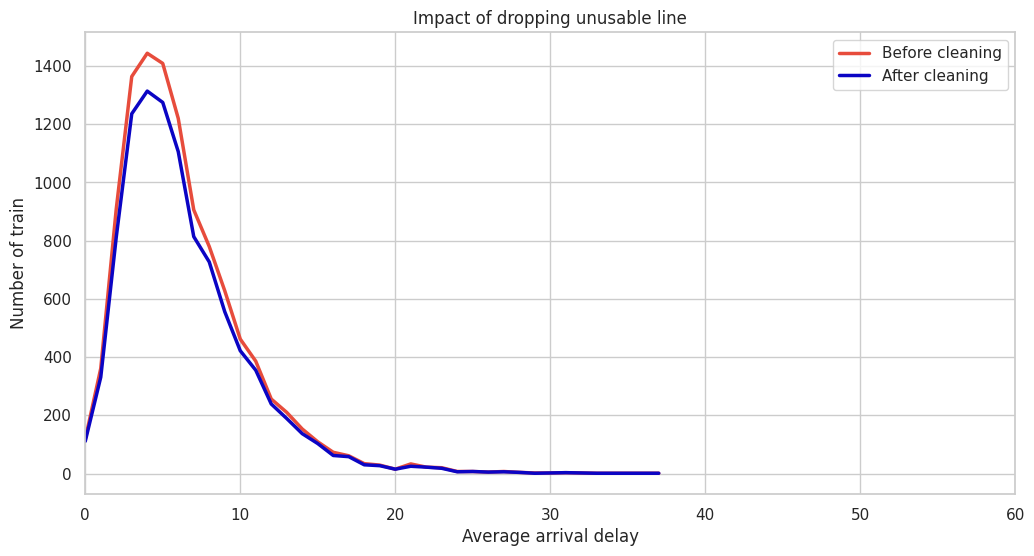

In [183]:
# Set the background of the graph to a clean white grid
sns.set_theme(style="whitegrid")
# Round the delay times to whole numbers, then count how many times each delay occurred (BEFORE cleaning)
counts_before = old_df['Average delay of all trains at arrival'].round().value_counts()
# Do the exact same counting for the new dataset (AFTER cleaning)
counts_after = df['Average delay of all trains at arrival'].round().value_counts()
# Create a new blank graph window with a specific width (12) and height (6)
plt.figure(figsize=(12, 6))
# Draw the red line showing the data BEFORE the cleaning process
sns.lineplot(
    x=counts_before.index,   # Horizontal axis: The delay time in minutes (0, 1, 2...)
    y=counts_before.values,  # Vertical axis: How many trains experienced this exact delay
    color='#e74c3c',       # Set the line color to red
    linewidth=2.5,           # Make the line slightly thicker so it is easy to see
    label='Before cleaning'  # Add the name for the legend
)
# Draw the blue line showing the data AFTER the cleaning process
sns.lineplot(
    x=counts_after.index,    # Horizontal axis: The delay time in minutes
    y=counts_after.values,   # Vertical axis: How many trains experienced this exact delay
    color='#0b04c4',       # Set the line color to dark blue
    linewidth=2.5,           # Make the line slightly thicker
    label='After cleaning'   # Add the name for the legend
)
# Add the main title at the very top of the graph
plt.title("Impact of dropping unusable line")
# Add text labels explaining what the horizontal and vertical axes represent
plt.xlabel("Average arrival delay")
plt.ylabel("Number of train")
# Force the horizontal axis to only show values from 0 to 60 (to zoom in on the most important part)
plt.xlim(0, 60) 
# Display the legend box (the little box that says Red = Before, Blue = After)
plt.legend()
# Display the completed graph on the screen
plt.show()

**Result:** The chart shows that the broken rows were successfully removed. Our code worked correctly!

***
### 🩹 **Step 4 : Handling all null or missing values :**

**Our Strategy :** Not all missing values (NaN) should be treated the same way. We use different rules depending on the column :

* **Text Columns:** We replace missing comments with `"None"` so we know there was no comment.
* **Number Columns:** We replace missing counts or percentages with `0` because it means nothing happened.
* **Journey Time:** We replace missing times with the **median** (the middle value). This fixes the empty spaces without changing the overall statistics.

Number of null values ​​in each column before :

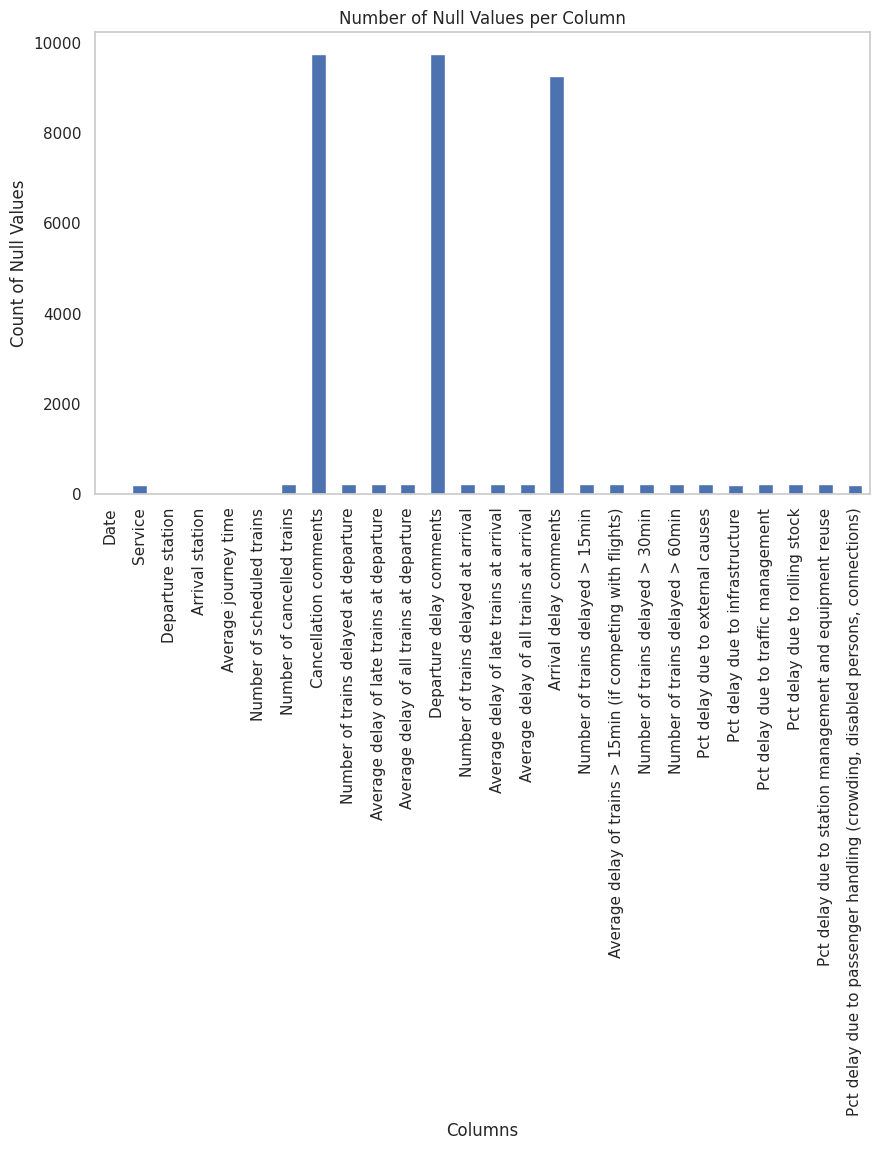

In [184]:
# Count how many empty (null) values exist in each column of the dataset
null_counts = df.isnull().sum()
# Create a new blank graph window with a specific width (10) and height (6)
plt.figure(figsize=(10, 6))
# Draw a vertical bar chart using the empty value counts we just calculated
null_counts.plot(kind='bar')
# Add the main title at the top of the graph
plt.title("Number of Null Values per Column")
# Add a text label for the horizontal axis (the names of the columns)
plt.xlabel("Columns")
# Add a text label for the vertical axis (the number of empty boxes)
plt.ylabel("Count of Null Values")
# Remove the background grid lines to make the graph look cleaner
plt.grid(False)
# Force the vertical axis to start exactly at zero
plt.ylim(0)
# Display the final graph on the screen (Don't forget the parentheses here!)
plt.show()

In [185]:
null_val_to_zero = [
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

#replaces all null values ​​in the "cols_to_string" list with "None"
df[cols_to_string] = df[cols_to_string].fillna("None")
#replaces all null values ​​in the "null_val_to_zero" list with "0"
df[null_val_to_zero] = df[null_val_to_zero].fillna(0)
#recovery of median travel time
median_val = df['Average journey time'].median()
#Replacing null values ​​in the "Average journey time" column with the median value allows the rows to be used without impacting the average journey time result.
df['Average journey time'] = df['Average journey time'].fillna(median_val)

**Number of null values ​​in each column after :**

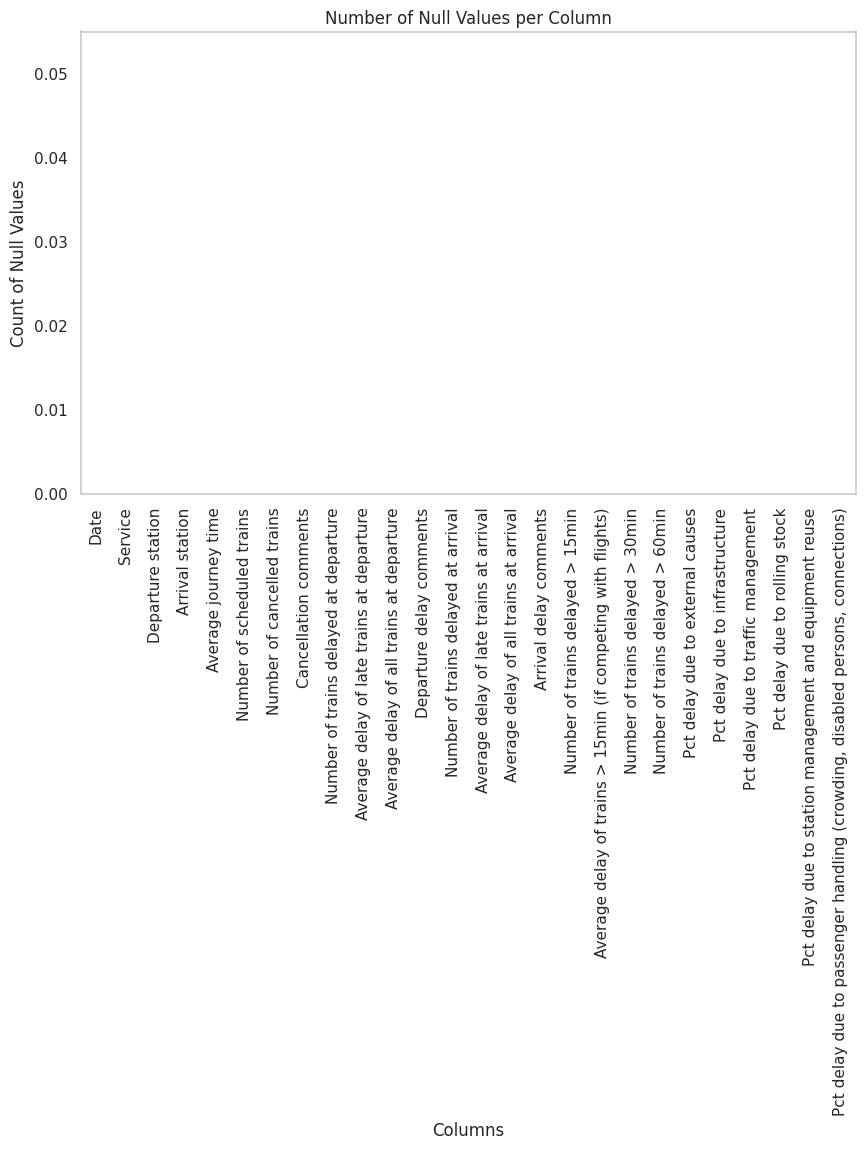

In [186]:
# Count how many empty (null) values exist in each column of the dataset
null_counts = df.isnull().sum()
# Create a new blank graph window with a specific width (10) and height (6)
plt.figure(figsize=(10, 6))
# Draw a vertical bar chart using the empty value counts we just calculated
null_counts.plot(kind='bar')
# Add the main title at the top of the graph
plt.title("Number of Null Values per Column")
# Add a text label for the horizontal axis (the names of the columns)
plt.xlabel("Columns")
# Add a text label for the vertical axis (the number of empty boxes)
plt.ylabel("Count of Null Values")
# Remove the background grid lines to make the graph look cleaner
plt.grid(False)
# Force the vertical axis to start exactly at zero
plt.ylim(0)
# Display the final graph on the screen (Don't forget the parentheses here!)
plt.show()

**Result:** we now have no null values !

***
## 🧹 Step 5: Clean Extra Spaces
***

### **Our Strategy:**
**Sometimes, text columns like station names have invisible spaces at the beginning or the end (for example: `" PARIS LYON "` instead of `"PARIS LYON"`).** 
**We use the `.str.strip()` command to remove these hidden spaces so the text matches perfectly.**

In [187]:
old_df = df.copy()
# Remove invisible spaces from the 'Service' column
df['Service'] = df['Service'].str.strip().str.upper()
# Remove invisible spaces from the 'Departure station' column
df['Departure station'] = df['Departure station'].str.strip().str.upper()
# Remove invisible spaces from the 'Arrival station' column
df['Arrival station'] = df['Arrival station'].str.strip().str.upper()

<Figure size 1000x600 with 0 Axes>

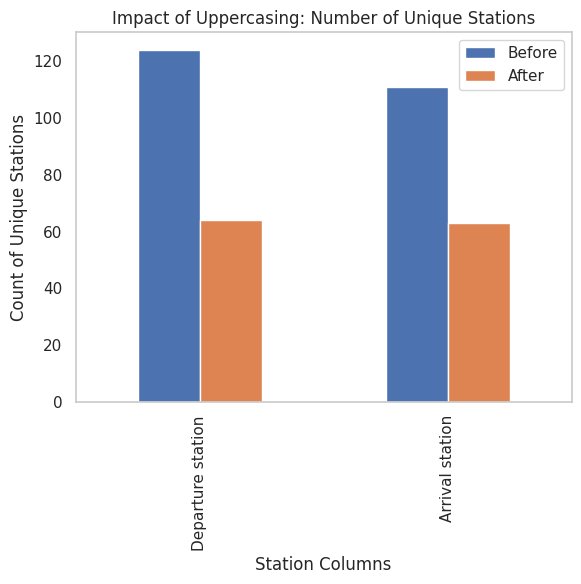

In [188]:
# Create a small summary table to compare the data before and after cleaning
data = pd.DataFrame({
    # Count the number of unique (different) station names in the old dataset
    'Before': old_df[['Departure station', 'Arrival station']].nunique(),
    # Count the number of unique station names in the new dataset (after fixing uppercase/lowercase)
    'After': df[['Departure station', 'Arrival station']].nunique()
})
# Create a new blank graph window with a specific width (10) and height (6)
plt.figure(figsize=(10, 6))
# Draw a bar chart using the summary table we just created above
data.plot(kind='bar')
# Add the main title at the top of the graph
plt.title("Impact of Uppercasing: Number of Unique Stations")
# Add a text label for the horizontal axis
plt.xlabel("Station Columns")
# Add a text label for the vertical axis
plt.ylabel("Count of Unique Stations")
# Remove the background grid lines to keep the graph looking clean
plt.grid(False)

# Display the final graph on the screen
plt.show()

***
## 🏗️ Step 6: Create New Columns
***

### **Our Strategy:**
**To help our future prediction models, we extract new information from the `Date` column: the month, the year, and the quarter.**
**We also create a `delay_category` column by rounding the arrival delays to the nearest minute.**

In [189]:
import numpy as np
# Extract the month number from the Date column
df['Month'] = df['Date'].dt.month
# Extract the year number from the Date column
df['Year'] = df['Date'].dt.year
#create route columns
df['Route'] = df['Departure station'] + '-' + df['Arrival station']
#create Cancellation_Rate column
df['Cancellation_Rate'] = df['Number of cancelled trains'] / df['Number of scheduled trains']
#create size_delay column
df['Size_delay'] = df['Average delay of late trains at arrival'] / df['Average journey time']
#create Delay_Evolution column
df['Delay_Evolution'] = df['Average delay of all trains at arrival'] - df['Average delay of all trains at departure']
#create Internal_Fault column
df['Internal_Fault_pct'] = df['Pct delay due to infrastructure'] + df['Pct delay due to traffic management'] + df['Pct delay due to rolling stock'] + df['Pct delay due to station management and equipment reuse']
#create External_Fault column
df['External_Fault_pct'] = df['Pct delay due to external causes'] + df['Pct delay due to passenger handling (crowding, disabled persons, connections)']
#create real_nb_train column
df['real_nb_train'] = df['Number of scheduled trains'] - df['Number of cancelled trains']
#create Delay_Probability column
df['Delay_Probability'] = df['Number of trains delayed at arrival'] / df['real_nb_train']
df['Delay_Probability'] = df['Delay_Probability'].replace([np.inf], 0)
df['Delay_Probability'] = df['Delay_Probability'].fillna(0)

***
## 🗑️ Step 7: Delete Useless Columns
***

### **Our Strategy:**
**The comment columns contain too much text and are not useful for our prediction models. We delete them to keep our dataset clean and lightweight.**

In [ ]:
columns_to_delete = [
   'Arrival delay comments',
   'Cancellation comments',
   'Departure delay comments',
   'Date',
   'Number of scheduled trains',
   'Number of cancelled trains',
   'Pct delay due to external causes',
   'Pct delay due to infrastructure',
   'Pct delay due to traffic management',
   'Pct delay due to rolling stock',
   'Pct delay due to station management and equipment reuse',
   'Pct delay due to passenger handling (crowding, disabled persons, connections)',
   'Number of trains delayed at departure',
   'Number of trains delayed at arrival',
   'Average delay of late trains at departure',
   'Average delay of late trains at arrival',
   'Number of trains delayed > 15min',
   'Average delay of trains > 15min (if competing with flights)',
   'Number of trains delayed > 30min',
   'Number of trains delayed > 60min'
]

# Drop the selected columns from the dataset
df = df.drop(columns=columns_to_delete, errors='ignore')

***
## 💾 Step 8: Export Cleaned Dataset
***

### **Final Result:**
**Our data is now perfectly clean with no missing values and the correct types. We save the final dataset into a new CSV file called `cleaned_dataset.csv`.**

In [191]:
# Name of the output file
output_file = "cleaned_dataset.csv"
# Save the clean dataframe to a CSV file without the index column
df.to_csv(output_file, index=False)
# Print the final summary of the dataset (types and row count)
df.info()

<class 'pandas.DataFrame'>
Index: 10231 entries, 0 to 12060
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Service                                   10231 non-null  string 
 1   Average journey time                      10231 non-null  Float64
 2   Number of scheduled trains                10231 non-null  Float64
 3   Number of cancelled trains                10231 non-null  Float64
 4   Average delay of all trains at departure  10231 non-null  Float64
 5   Average delay of all trains at arrival    10231 non-null  Float64
 6   Month                                     10231 non-null  int64  
 7   Year                                      10231 non-null  int64  
 8   Route                                     10231 non-null  string 
 9   Cancellation_Rate                         10231 non-null  Float64
 10  Size_delay                                10231 no

***

# 🧼 **DATA ANALYSE** #

---
### **analyse the dataset with some graphics**
---

list of graphics :

* **1. Fix Data Types** We change each column to the right type. For example, we convert text into numbers so the computer can read them correctly.

* **2. Delete aberrant values** We remove aberrant values.
  
* **3. Remove Broken Rows** We delete rows that are missing important information because we cannot use them.
  
* **4. Fill Empty Spaces** If some columns have missing values, we fill them with 0, None or an average number.
  
* **5. Clean Extra Spaces** We remove invisible spaces at the beginning and the end of text columns (like station names) so they match perfectly.
  
* **6. Create New Columns** We build new information (features) from our data to help our prediction models work better later.

* **7. Delete Useless Columns** We remove text columns (like comments) that we do not need for our machine learning models.

* **8. Export Cleaned Dataset** We save our final, perfectly clean data into a new CSV file.
---

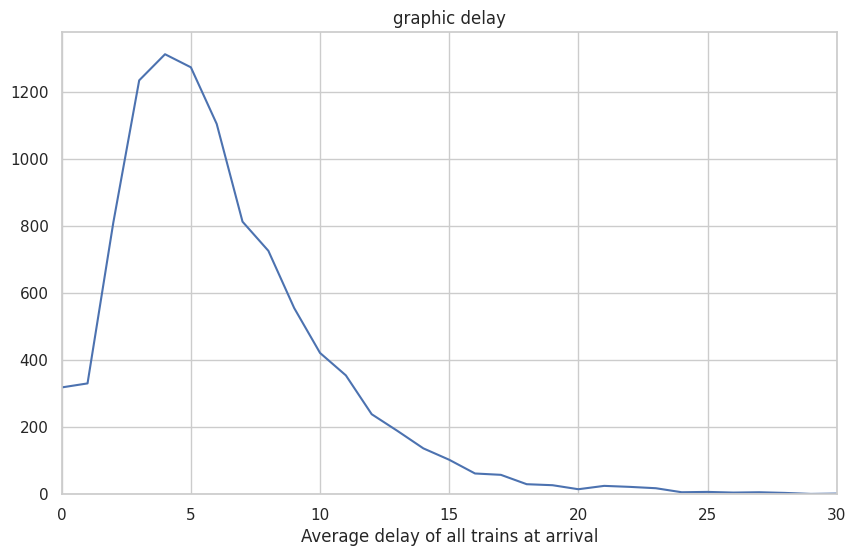

In [192]:
counts = df['Average delay of all trains at arrival'].round().value_counts()

plt.figure(figsize=(10, 6))
sns.lineplot(x=counts.index, y=counts.values)
#add limite to x axe
plt.xlim(0, 30)
#add limite to y axe
plt.ylim(0)
#add title to the graphic
plt.title("graphic delay")
#show graphic
plt.show()

graphic delay
USE : print a graphic delay (line graph)
PARAMS : df (dataset)
RETURN : line graph of "delay"

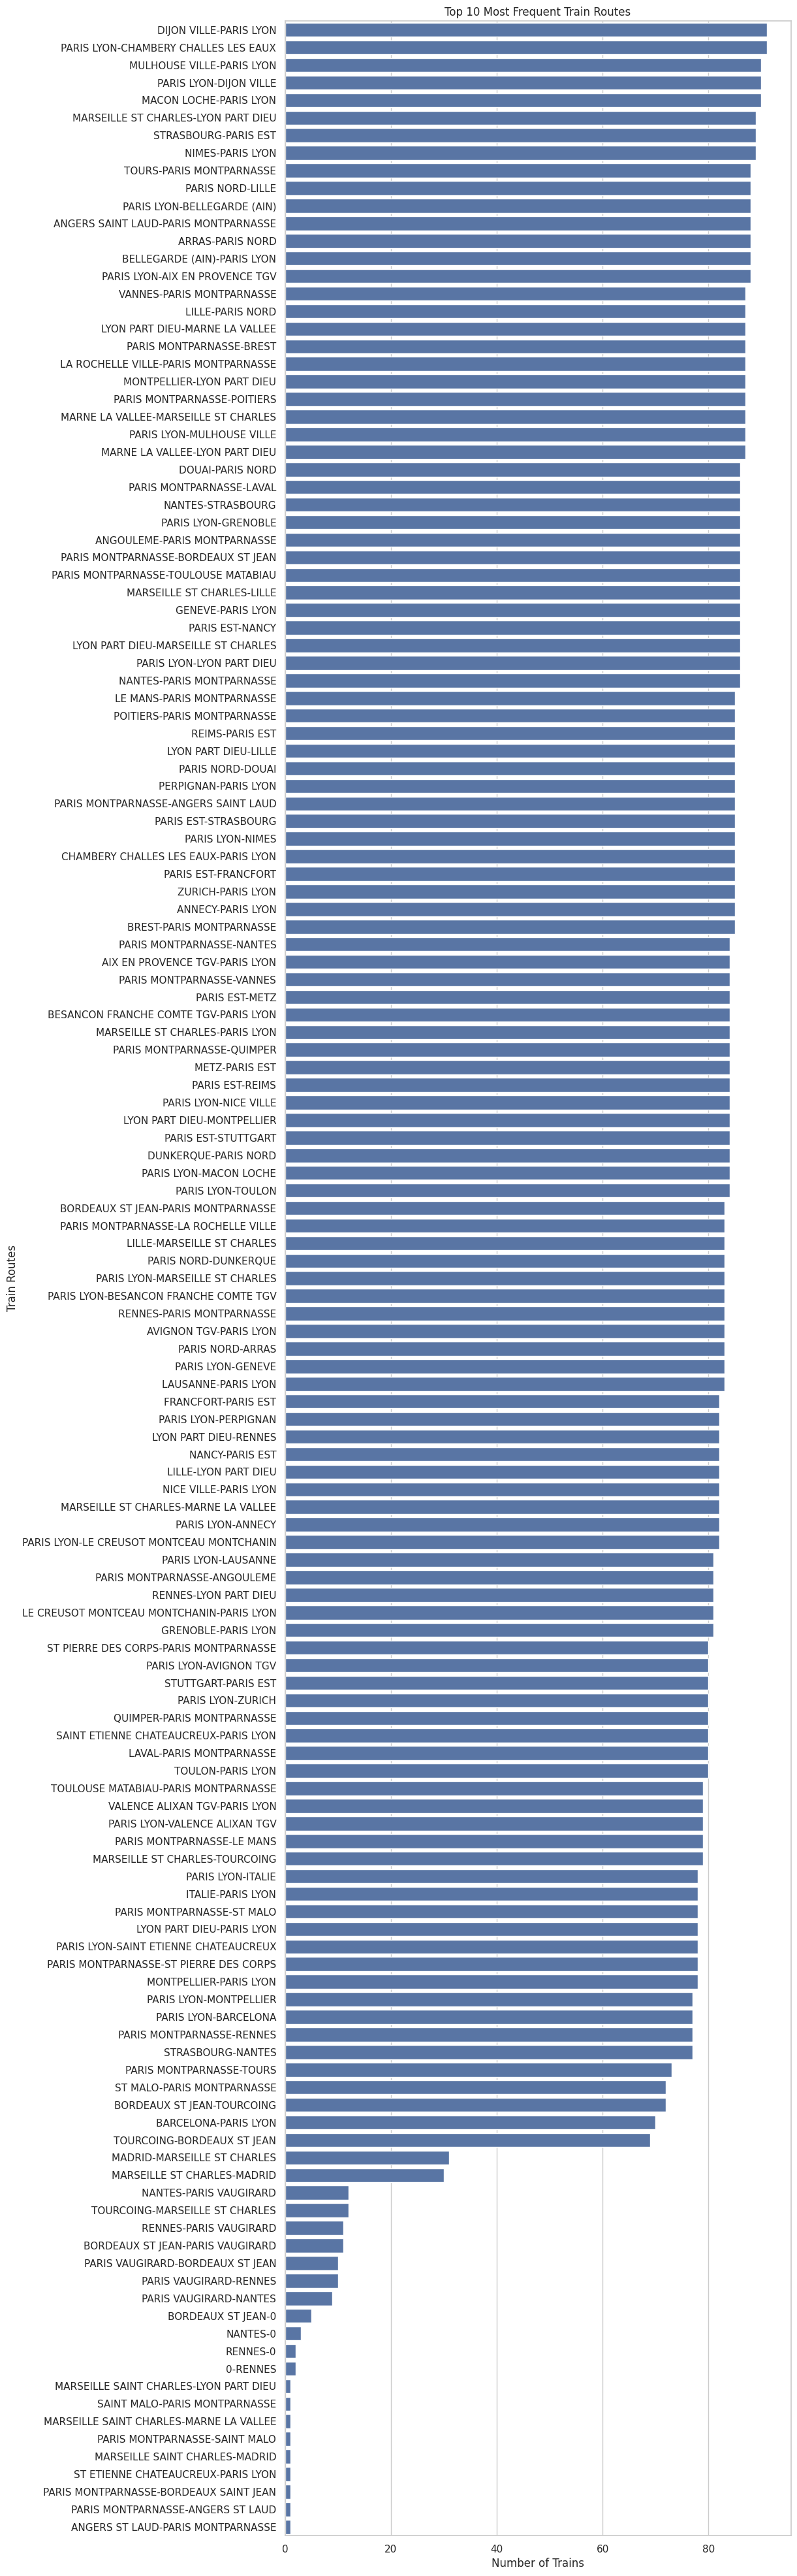

In [193]:
sort_route = df['Route'].value_counts().index
plt.figure(figsize=(10, 50))
sns.countplot(data=df, y='Route', order=sort_route)
plt.title("Top 10 Most Frequent Train Routes")
plt.xlabel("Number of Trains")
plt.ylabel("Train Routes")
plt.show()

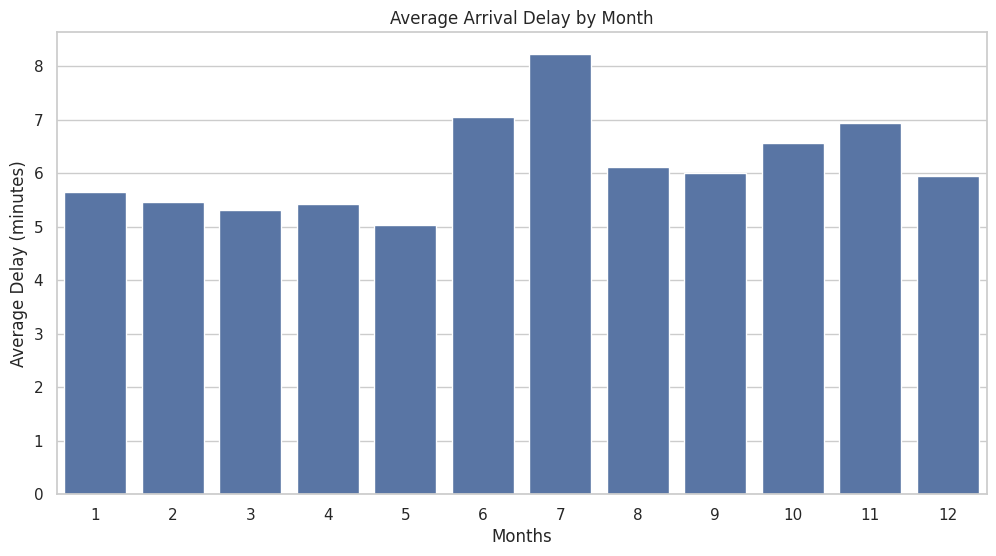

In [194]:
monthly_delay = df.groupby('Month')['Average delay of all trains at arrival'].mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_delay.index, y=monthly_delay.values)
plt.title("Average Arrival Delay by Month")
plt.xlabel("Months")
plt.ylabel("Average Delay (minutes)")
plt.show()

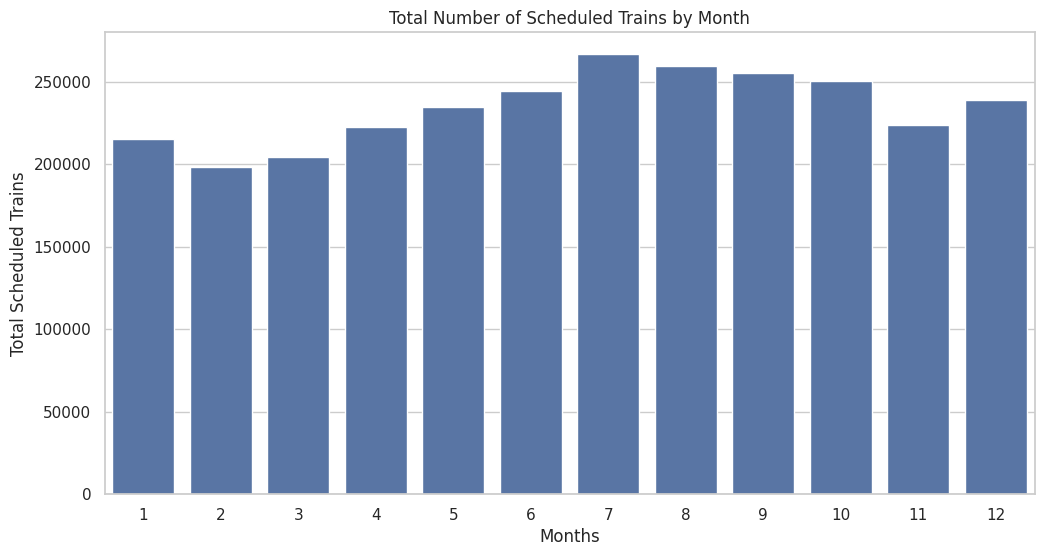

In [195]:
monthly_train_count = df.groupby('Month')['Number of scheduled trains'].sum()
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_train_count.index, y=monthly_train_count.values)
plt.title("Total Number of Scheduled Trains by Month")
plt.xlabel("Months")
plt.ylabel("Total Scheduled Trains")
plt.show()

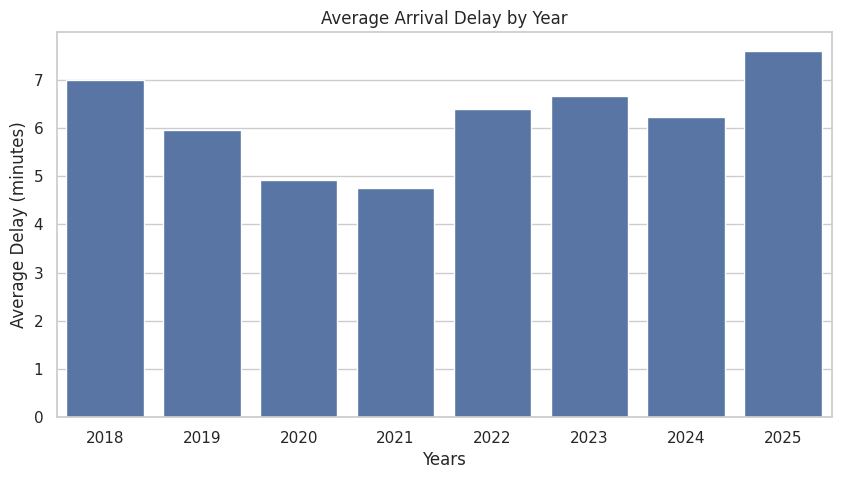

In [196]:
yearly_delay = df.groupby('Year')['Average delay of all trains at arrival'].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_delay.index, y=yearly_delay.values)
plt.title("Average Arrival Delay by Year")
plt.xlabel("Years")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
def plot_delay_dispersion(dataset, graph, titre, couleur):
    sns.scatterplot(
        data=dataset, 
        x='Average delay of all trains at departure', 
        y='Average delay of all trains at arrival',
        color=couleur, 
        alpha=0.6,
        ax = graph
    )
    graph.set_title(titre, fontweight='bold')
    graph.set_xlabel("late departure")
    graph.set_ylabel("late arrived")

df_no_clean = pd.read_csv("dataset.csv", sep=";")

for col in ['Average delay of all trains at departure', 'Average delay of all trains at arrival']:
    #convert columns to a str type
    df_no_clean[col] = df_no_clean[col].astype("string")
    #replace all ',' to '.' to transform into numeric
    df_no_clean[col] = df_no_clean[col].str.replace(',', '.')
    #Remove all the "min" characters so that you can then convert to numeric without any problems.
    df_no_clean[col] = df_no_clean[col].str.replace(' min', '')
    #Remove all the "%" characters so that you can then convert to numeric without any problems.
    df_no_clean[col] = df_no_clean[col].str.replace('%', '')
    #Converted the column to numeric type (string to numeric)
    df_no_clean[col] = pd.to_numeric(df_no_clean[col], errors='coerce')
def scatterplot_graphique(df_before, df_after):
    fig = plt.figure(figsize=(14, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    plot_delay_dispersion(df_before, ax1, "Before cleaning", "#e74c3c")
    plot_delay_dispersion(df_after, ax2, "After cleaning", "#2ecc71")
    plt.tight_layout()
    plt.show()